# Distributions & Proportions — Demo Notebook
### Unit 1, Lecture 7 — Visualization of Data, Understanding and Interpretation (UE24CS342AA9)

Use the **Titanic passenger dataset** 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

titanic = sns.load_dataset("titanic")
print("Shape:", titanic.shape)
print("Passengers with known age:", titanic["age"].notna().sum())
titanic.head()

Shape: (891, 15)
Passengers with known age: 714


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1. Histograms — Visualizing a Distribution (Sec 7.1)

A histogram groups continuous data into **bins** and shows the count of observations in each bin.

- X-axis: value ranges (Age)
- Y-axis: number of observations (Count)

Let's plot the age distribution of Titanic passengers.

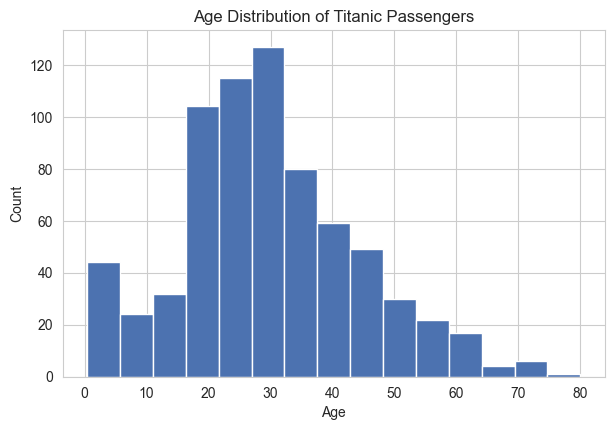

In [2]:
ages = titanic["age"].dropna()

plt.figure()
plt.hist(ages, bins=15, color="#4C72B0", edgecolor="white")
plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## 2. Choosing the Right Bin Width (Sec 7.1)

The *same data* can look very different depending on bin width:
- **Too small** → noisy, too many peaks
- **Appropriate** → shows the overall trend clearly
- **Too large** → hides important patterns

Below we reproduce the three bin-width regimes discussed in the slides using `age` bins of
roughly 1 year, 5 years, and 15 years.

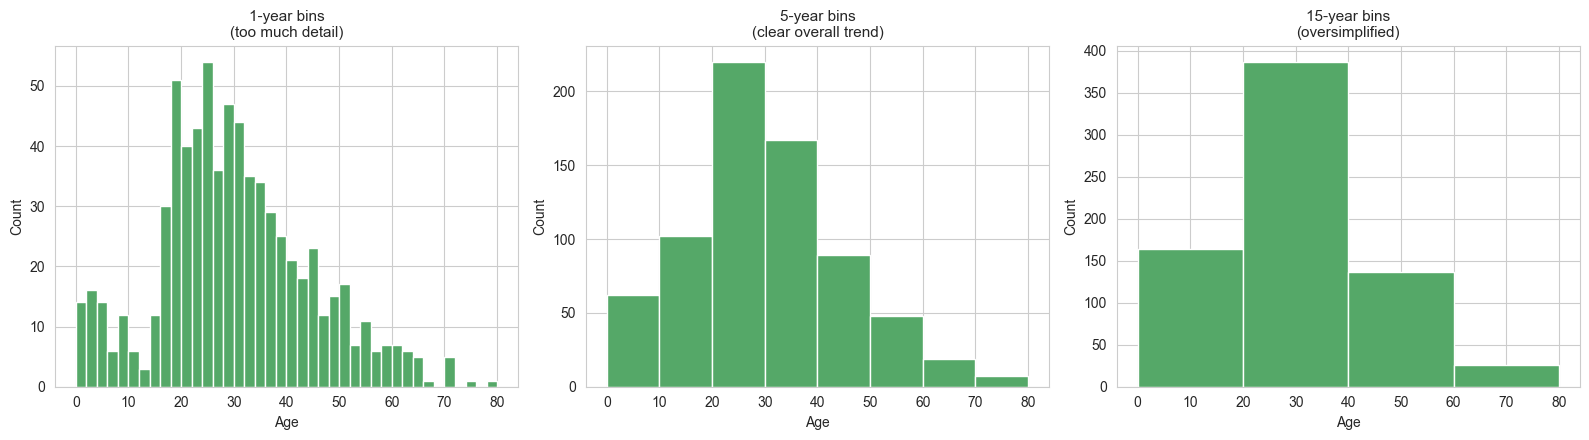

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)

bin_configs = [
    (np.arange(0, 81, 2), "1-year bins\n(too much detail)"),
    (np.arange(0, 81, 10), "5-year bins\n(clear overall trend)"),
    (np.arange(0, 81, 20), "15-year bins\n(oversimplified)"),
]

for ax, (bins, title) in zip(axes, bin_configs):
    ax.hist(ages, bins=bins, color="#55A868", edgecolor="white")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Age")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

**Try it yourself:** change the bin widths above (e.g. 2, 10, 20 years) and re-run.
At what bin width do you start losing the visible bump around childhood ages (0–10)?

## 3. Density Plots & Kernel Density Estimation (Sec 7.1)

A **density plot** estimates the underlying continuous probability distribution instead of
grouping data into bins. **KDE** builds this curve by:

1. Placing a small smooth kernel on every data point
2. Adding all the kernels together
3. Normalizing so the total area under the curve equals 1

Let's overlay a KDE curve on the histogram.

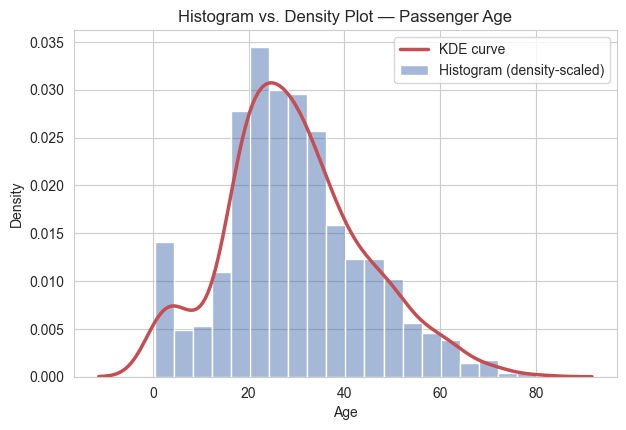

In [4]:
plt.figure()
sns.histplot(ages, bins=20, stat="density", color="#4C72B0", edgecolor="white", alpha=0.5, label="Histogram (density-scaled)")
sns.kdeplot(ages, color="#C44E52", linewidth=2.5, label="KDE curve")
plt.title("Histogram vs. Density Plot — Passenger Age")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.show()

## 4. Bandwidth — the KDE Equivalent of Bin Width (Sec 7.1)

Bandwidth controls how smooth the KDE curve is:
- **Small bandwidth** → wavy, noisy curve
- **Large bandwidth** → over-smoothed, hides real structure

`seaborn.kdeplot` exposes this through the `bw_adjust` parameter (a multiplier on the
default bandwidth).

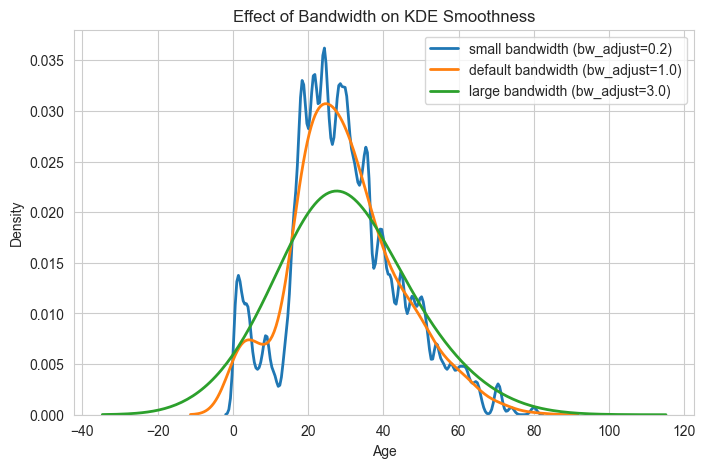

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

for bw, style in [(0.2, "small bandwidth (bw_adjust=0.2)"),
                   (1.0, "default bandwidth (bw_adjust=1.0)"),
                   (3.0, "large bandwidth (bw_adjust=3.0)")]:
    sns.kdeplot(ages, bw_adjust=bw, label=style, linewidth=2, ax=ax)

ax.set_title("Effect of Bandwidth on KDE Smoothness")
ax.set_xlabel("Age")
ax.set_ylabel("Density")
ax.legend()
plt.show()

**Try it yourself:** set `bw_adjust` to something extreme like `0.05` or `10`. Which
bandwidth would you actually choose to present to a non-technical audience, and why?

## 5. A Pitfall of Density Plots (Sec 7.1)

Density estimation can assign a small probability to regions where **no real data can
exist** — e.g. negative ages. This is one reason to always sanity-check a KDE against the
actual range of the data.

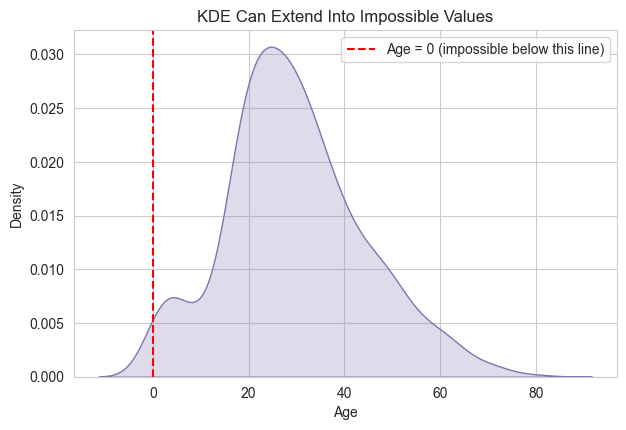

Minimum x-value where the KDE has non-negligible density is slightly below 0,
even though no passenger can have a negative age. This is the pitfall discussed in class.


In [18]:
plt.figure()
sns.kdeplot(ages, bw_adjust=1.0, fill=True, color="#8172B2")
plt.axvline(0, color="red", linestyle="--", label="Age = 0 (impossible below this line)")
plt.title("KDE Can Extend Into Impossible Values")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.show()

print("Minimum x-value where the KDE has non-negligible density is slightly below 0,")
print("even though no passenger can have a negative age. This is the pitfall discussed in class.")

## 6. Visualizing Proportions — Pie vs. Bar vs. Stacked Bar (Sec 10.1)

Now let's look at **proportions**: how passenger class breaks down by survival outcome.

We'll build the *same* underlying data three different ways and compare how easy each
makes it to answer: *"Which class had the highest survival rate?"*

In [19]:
prop_data = (
    titanic.groupby("pclass")["survived"]
    .value_counts(normalize=True)
    .unstack()
    .rename(columns={0: "Did not survive", 1: "Survived"})
)
prop_data

survived,Did not survive,Survived
pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


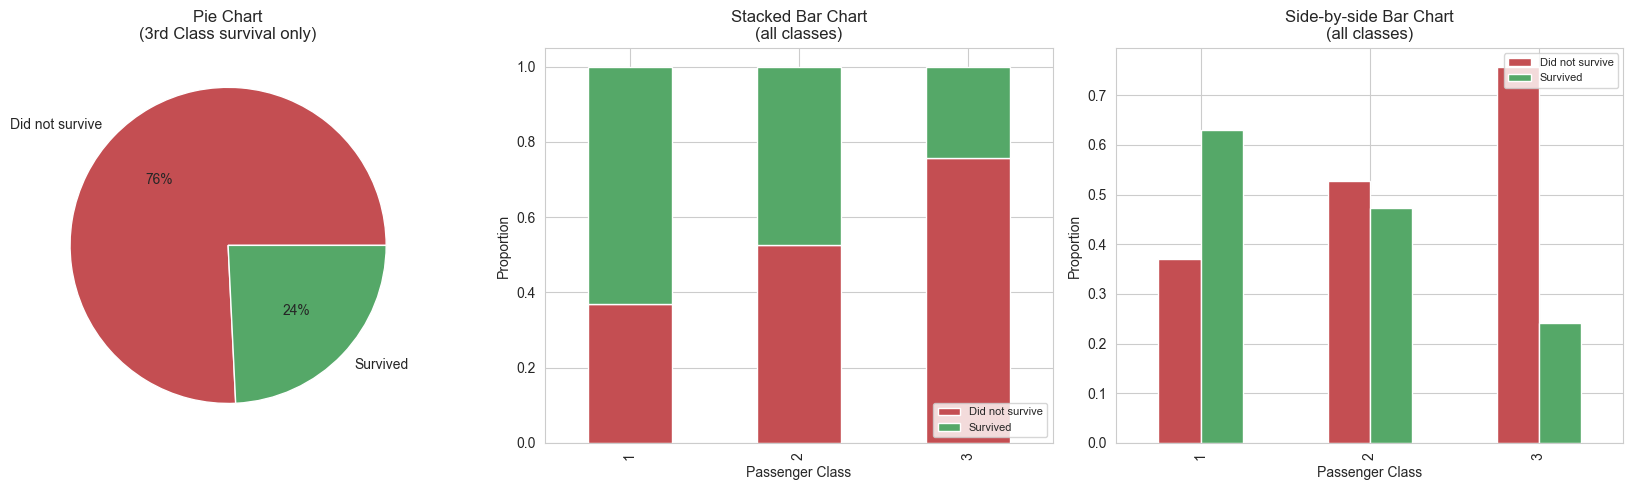

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Pie chart (single class, e.g. 3rd class) -- pie charts don't scale well to multiple groups
axes[0].pie(prop_data.loc[3], labels=prop_data.columns, autopct="%1.0f%%",
            colors=["#C44E52", "#55A868"])
axes[0].set_title("Pie Chart\n(3rd Class survival only)")

# Stacked bar chart across all classes
prop_data.plot(kind="bar", stacked=True, ax=axes[1], color=["#C44E52", "#55A868"])
axes[1].set_title("Stacked Bar Chart\n(all classes)")
axes[1].set_xlabel("Passenger Class")
axes[1].set_ylabel("Proportion")
axes[1].legend(loc="lower right", fontsize=8)

# Side-by-side bar chart across all classes
prop_data.plot(kind="bar", stacked=False, ax=axes[2], color=["#C44E52", "#55A868"])
axes[2].set_title("Side-by-side Bar Chart\n(all classes)")
axes[2].set_xlabel("Passenger Class")
axes[2].set_ylabel("Proportion")
axes[2].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

**Discussion prompt:**
- Which of the three charts made it easiest to compare *survival rate across classes*?
- Why does a pie chart struggle here even though it works fine for a single class?
- The slides note that stacked bars make **middle segments** hard to compare because they
  don't share a common baseline — can you see that effect in the stacked chart above?



| Concept | What you did |
|---|---|
| Histogram bin width | Compared 1-yr / 5-yr / 15-yr bins on the same data |
| Density plot & KDE | Overlaid a smooth KDE curve on a histogram |
| Bandwidth | Varied `bw_adjust` to see under/over-smoothing |
| KDE pitfall | Observed density leaking below age = 0 |
| Proportions | Compared pie, stacked bar, and side-by-side bar for the same data |
